In [1]:
import json
import sys
import time
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def find_project_root(start_path: Path) -> Path:
    """Find the project directory containing src/config.py."""
    current_path = start_path.resolve()

    for candidate in [current_path, *current_path.parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/config.py."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

PROCESSED_DIR = Path(PROCESSED_DATA_DIR)
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

FEATURE_FILE = PROCESSED_DIR / "audio_features.csv"
MODEL_COMPARISON_FILE = REPORT_DIR / "ml_model_comparison.csv"
BEST_MODEL_FILE = MODEL_DIR / "music_genre_ml.joblib"
MODEL_METADATA_FILE = MODEL_DIR / "music_genre_ml_metadata.json"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Python executable:", sys.executable)
print("Scikit-learn version:", sklearn.__version__)
print("Project root:", PROJECT_ROOT)
print("Feature file:", FEATURE_FILE)
print("Feature file exists:", FEATURE_FILE.exists())

if ".venv" not in sys.executable:
    raise RuntimeError(
        "Wrong kernel selected. Choose the project .venv kernel."
    )

if not FEATURE_FILE.exists():
    raise FileNotFoundError(
        "audio_features.csv was not found. "
        "Run 04_feature_extraction.ipynb first."
    )

Python executable: d:\Projects\music-genre-classification-AI\.venv\Scripts\python.exe
Scikit-learn version: 1.9.0
Project root: D:\Projects\music-genre-classification-AI
Feature file: D:\Projects\music-genre-classification-AI\data\processed\audio_features.csv
Feature file exists: True


In [2]:
feature_df = pd.read_csv(FEATURE_FILE)

required_columns = {
    "file_path",
    "filename",
    "genre",
    "split",
}

missing_columns = required_columns - set(feature_df.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

feature_df = (
    feature_df
    .drop_duplicates(subset=["file_path"])
    .reset_index(drop=True)
)

metadata_columns = [
    "file_path",
    "filename",
    "genre",
    "split",
]

feature_columns = [
    column
    for column in feature_df.select_dtypes(
        include=[np.number]
    ).columns
    if column not in metadata_columns
]

if not feature_columns:
    raise ValueError(
        "No numerical feature columns were found."
    )

feature_df[feature_columns] = (
    feature_df[feature_columns]
    .replace([np.inf, -np.inf], np.nan)
)

missing_value_count = int(
    feature_df[feature_columns]
    .isna()
    .sum()
    .sum()
)

print("Dataset rows:", len(feature_df))
print("Numerical features:", len(feature_columns))
print("Genres:", feature_df["genre"].nunique())
print("Missing feature values:", missing_value_count)

display(
    feature_df["split"]
    .value_counts()
    .reindex(["train", "validation", "test"])
    .rename("track_count")
    .to_frame()
)

display(feature_df.head())

Dataset rows: 999
Numerical features: 90
Genres: 10
Missing feature values: 0


,track_count
split,
train,699
validation,150
test,150


,file_path,filename,genre,split,loaded_duration_seconds,tempo_bpm,mfcc_01_mean,mfcc_01_std,mfcc_02_mean,mfcc_02_std,...,spectral_contrast_03_mean,spectral_contrast_03_std,spectral_contrast_04_mean,spectral_contrast_04_std,spectral_contrast_05_mean,spectral_contrast_05_std,spectral_contrast_06_mean,spectral_contrast_06_std,spectral_contrast_07_mean,spectral_contrast_07_std
0,data\raw\genres_original\country\country.00061...,country.00061.wav,country,train,30.0,123.046875,-482.063802,68.180736,135.860073,28.998235,...,23.540774,4.545851,21.173070,3.812318,21.600273,3.830388,19.884863,3.602342,37.326387,4.477069
1,data\raw\genres_original\classical\classical.0...,classical.00046.wav,classical,validation,30.0,129.199219,-373.008461,23.495534,118.423067,19.340320,...,18.463920,3.502241,19.849700,2.520823,20.713156,2.359407,20.558529,2.448312,21.254693,2.730834
2,data\raw\genres_original\country\country.00005...,country.00005.wav,country,train,30.0,129.199219,-393.541695,27.496700,62.388383,15.932810,...,19.019879,4.381183,19.061713,3.924187,19.638747,3.195603,17.685056,2.671622,17.485123,2.074316
3,data\raw\genres_original\disco\disco.00049.wav,disco.00049.wav,disco,train,30.0,123.046875,-437.577377,60.125883,98.671647,30.238519,...,17.128404,4.040533,16.994300,3.413414,18.271373,3.387091,18.764664,3.561410,42.711696,6.376284
4,data\raw\genres_original\hiphop\hiphop.00022.wav,hiphop.00022.wav,hiphop,validation,30.0,99.384014,-501.525654,73.550980,110.210732,29.239844,...,18.053938,4.430873,16.798288,3.913257,16.911758,3.270236,16.258567,2.861101,40.968474,4.152934


In [3]:
rows_with_missing_features = (
    feature_df[feature_columns]
    .isna()
    .any(axis=1)
)

if rows_with_missing_features.any():
    print(
        "Removing rows with missing features:",
        int(rows_with_missing_features.sum()),
    )

    display(
        feature_df.loc[
            rows_with_missing_features,
            metadata_columns,
        ]
    )

    feature_df = (
        feature_df.loc[
            ~rows_with_missing_features
        ]
        .reset_index(drop=True)
    )
else:
    print("No rows need to be removed.")

No rows need to be removed.


In [4]:
train_df = feature_df[
    feature_df["split"] == "train"
].copy()

validation_df = feature_df[
    feature_df["split"] == "validation"
].copy()

test_df = feature_df[
    feature_df["split"] == "test"
].copy()

if train_df.empty:
    raise ValueError("Training split is empty.")

if validation_df.empty:
    raise ValueError("Validation split is empty.")

if test_df.empty:
    raise ValueError("Test split is empty.")

X_train = train_df[feature_columns]
y_train = train_df["genre"]

X_validation = validation_df[feature_columns]
y_validation = validation_df["genre"]

# Do not use these during model selection.
X_test = test_df[feature_columns]
y_test = test_df["genre"]

genre_labels = sorted(
    feature_df["genre"].unique().tolist()
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)
print("Genre labels:", genre_labels)

Training shape: (699, 90)
Validation shape: (150, 90)
Test shape: (150, 90)
Genre labels: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [5]:
models = {
    "Logistic Regression": Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                LogisticRegression(
                    max_iter=5000,
                    C=1.0,
                ),
            ),
        ]
    ),

    "K-Nearest Neighbours": Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                KNeighborsClassifier(
                    n_neighbors=7,
                    weights="distance",
                ),
            ),
        ]
    ),

    "Support Vector Machine": Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "classifier",
                SVC(
                    kernel="rbf",
                    C=10.0,
                    gamma="scale",
                    probability=True,
                    random_state=42,
                ),
            ),
        ]
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
}

print("Models prepared:")

for model_name in models:
    print("-", model_name)

Models prepared:
- Logistic Regression
- K-Nearest Neighbours
- Support Vector Machine
- Random Forest


In [6]:
model_results = []
fitted_models = {}
validation_predictions = {}

for model_name, model in models.items():
    print(f"\nTraining: {model_name}")

    start_time = time.perf_counter()

    model.fit(
        X_train,
        y_train,
    )

    training_seconds = (
        time.perf_counter() - start_time
    )

    predictions = model.predict(
        X_validation
    )

    accuracy = accuracy_score(
        y_validation,
        predictions,
    )

    precision_macro = precision_score(
        y_validation,
        predictions,
        average="macro",
        zero_division=0,
    )

    recall_macro = recall_score(
        y_validation,
        predictions,
        average="macro",
        zero_division=0,
    )

    f1_macro = f1_score(
        y_validation,
        predictions,
        average="macro",
        zero_division=0,
    )

    fitted_models[model_name] = model
    validation_predictions[model_name] = predictions

    model_results.append(
        {
            "model": model_name,
            "validation_accuracy": accuracy,
            "validation_precision_macro": precision_macro,
            "validation_recall_macro": recall_macro,
            "validation_f1_macro": f1_macro,
            "training_seconds": training_seconds,
        }
    )

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(f"Training time: {training_seconds:.2f} seconds")

print("\nAll models finished.")


Training: Logistic Regression
Accuracy: 0.7667
Macro F1: 0.7676
Training time: 0.17 seconds

Training: K-Nearest Neighbours
Accuracy: 0.7200
Macro F1: 0.7193
Training time: 0.00 seconds

Training: Support Vector Machine


d:\Projects\music-genre-classification-AI\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy: 0.8267
Macro F1: 0.8256
Training time: 0.21 seconds

Training: Random Forest
Accuracy: 0.7733
Macro F1: 0.7717
Training time: 1.07 seconds

All models finished.


In [7]:
comparison_df = pd.DataFrame(
    model_results
)

comparison_df = (
    comparison_df
    .sort_values(
        by=[
            "validation_f1_macro",
            "validation_accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    comparison_df.style.format(
        {
            "validation_accuracy": "{:.4f}",
            "validation_precision_macro": "{:.4f}",
            "validation_recall_macro": "{:.4f}",
            "validation_f1_macro": "{:.4f}",
            "training_seconds": "{:.2f}",
        }
    )
)

best_model_name = comparison_df.loc[
    0,
    "model",
]

best_model = fitted_models[
    best_model_name
]

best_validation_predictions = (
    validation_predictions[
        best_model_name
    ]
)

print("Selected best model:", best_model_name)

,model,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,training_seconds
0,Support Vector Machine,0.8267,0.8297,0.8267,0.8256,0.21
1,Random Forest,0.7733,0.7752,0.7733,0.7717,1.07
2,Logistic Regression,0.7667,0.7858,0.7667,0.7676,0.17
3,K-Nearest Neighbours,0.7200,0.7423,0.7200,0.7193,0.00


Selected best model: Support Vector Machine


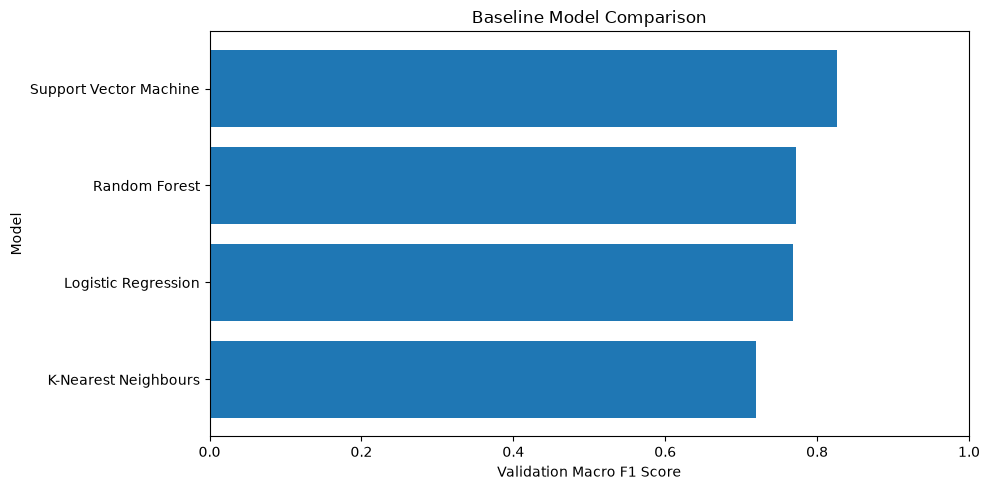

Figure saved to:
D:\Projects\music-genre-classification-AI\reports\figures\ml_model_comparison.png


In [8]:
plot_df = comparison_df.sort_values(
    "validation_f1_macro",
    ascending=True,
)

plt.figure(figsize=(10, 5))

plt.barh(
    plot_df["model"],
    plot_df["validation_f1_macro"],
)

plt.xlabel("Validation Macro F1 Score")
plt.ylabel("Model")
plt.title("Baseline Model Comparison")
plt.xlim(0, 1)
plt.tight_layout()

comparison_figure_path = (
    FIGURE_DIR / "ml_model_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:")
print(comparison_figure_path)

In [9]:
validation_report = classification_report(
    y_validation,
    best_validation_predictions,
    labels=genre_labels,
    target_names=genre_labels,
    digits=4,
    zero_division=0,
)

print(
    f"Validation report — {best_model_name}\n"
)

print(validation_report)

validation_report_path = (
    REPORT_DIR
    / "ml_validation_classification_report.txt"
)

validation_report_path.write_text(
    (
        f"Best model: {best_model_name}\n\n"
        f"{validation_report}"
    ),
    encoding="utf-8",
)

print("\nReport saved to:")
print(validation_report_path)

Validation report — Support Vector Machine

              precision    recall  f1-score   support

       blues     0.8462    0.7333    0.7857        15
   classical     1.0000    1.0000    1.0000        15
     country     0.6842    0.8667    0.7647        15
       disco     0.8571    0.8000    0.8276        15
      hiphop     0.8235    0.9333    0.8750        15
        jazz     0.9286    0.8667    0.8966        15
       metal     0.8667    0.8667    0.8667        15
         pop     0.8125    0.8667    0.8387        15
      reggae     0.7857    0.7333    0.7586        15
        rock     0.6923    0.6000    0.6429        15

    accuracy                         0.8267       150
   macro avg     0.8297    0.8267    0.8256       150
weighted avg     0.8297    0.8267    0.8256       150


Report saved to:
D:\Projects\music-genre-classification-AI\reports\ml_validation_classification_report.txt


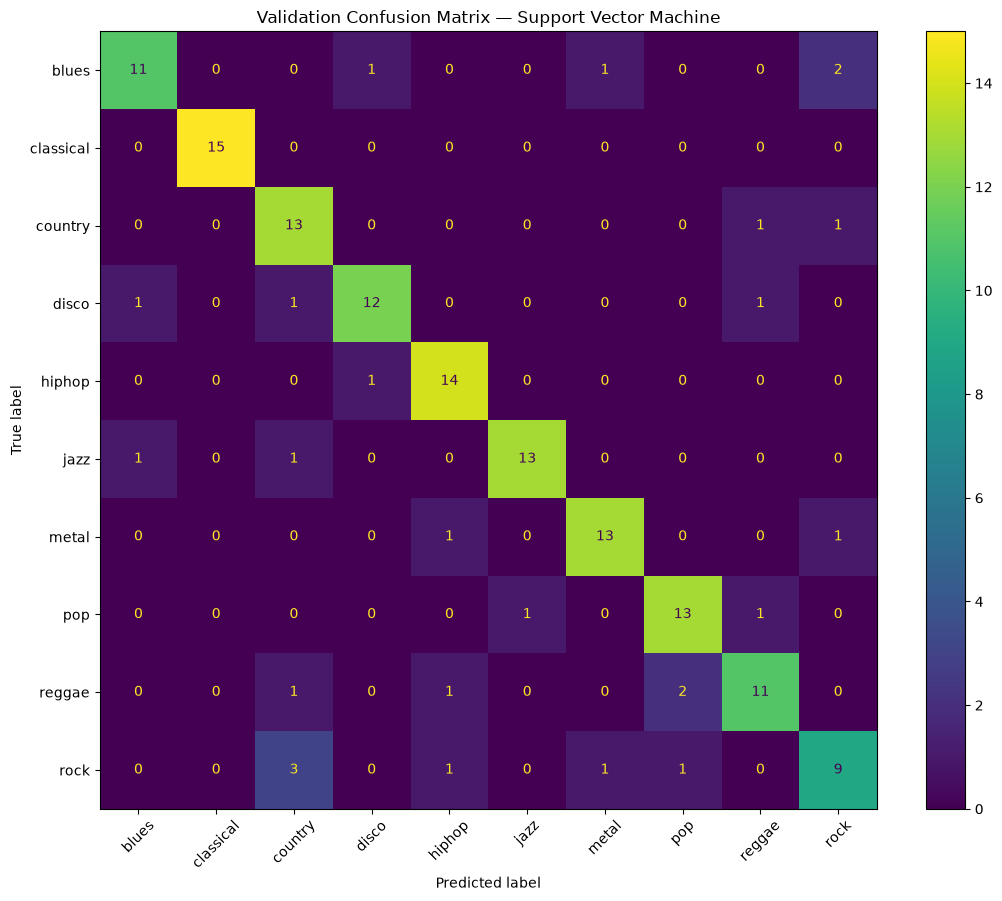

Confusion matrix saved to:
D:\Projects\music-genre-classification-AI\reports\figures\ml_validation_confusion_matrix.png


In [10]:
figure, axis = plt.subplots(
    figsize=(11, 9)
)

ConfusionMatrixDisplay.from_predictions(
    y_validation,
    best_validation_predictions,
    labels=genre_labels,
    display_labels=genre_labels,
    xticks_rotation=45,
    values_format="d",
    ax=axis,
)

axis.set_title(
    f"Validation Confusion Matrix — {best_model_name}"
)

figure.tight_layout()

confusion_matrix_path = (
    FIGURE_DIR
    / "ml_validation_confusion_matrix.png"
)

figure.savefig(
    confusion_matrix_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Confusion matrix saved to:")
print(confusion_matrix_path)

In [11]:
comparison_df.to_csv(
    MODEL_COMPARISON_FILE,
    index=False,
)

print("Model comparison saved to:")
print(MODEL_COMPARISON_FILE)

Model comparison saved to:
D:\Projects\music-genre-classification-AI\reports\ml_model_comparison.csv


In [12]:
joblib.dump(
    best_model,
    BEST_MODEL_FILE,
)

model_metadata = {
    "model_name": best_model_name,
    "feature_columns": feature_columns,
    "genre_labels": genre_labels,
    "selection_metric": "validation_f1_macro",
    "validation_accuracy": float(
        comparison_df.loc[
            0,
            "validation_accuracy",
        ]
    ),
    "validation_f1_macro": float(
        comparison_df.loc[
            0,
            "validation_f1_macro",
        ]
    ),
    "scikit_learn_version": sklearn.__version__,
    "python_version": sys.version,
}

MODEL_METADATA_FILE.write_text(
    json.dumps(
        model_metadata,
        indent=4,
    ),
    encoding="utf-8",
)

print("Best model saved to:")
print(BEST_MODEL_FILE)

print("\nModel metadata saved to:")
print(MODEL_METADATA_FILE)

Best model saved to:
D:\Projects\music-genre-classification-AI\models\music_genre_ml.joblib

Model metadata saved to:
D:\Projects\music-genre-classification-AI\models\music_genre_ml_metadata.json


In [13]:
loaded_model = joblib.load(
    BEST_MODEL_FILE
)

sample_validation_features = (
    X_validation.iloc[:5]
)

sample_actual_labels = (
    y_validation.iloc[:5]
    .reset_index(drop=True)
)

sample_predictions = loaded_model.predict(
    sample_validation_features
)

verification_df = pd.DataFrame(
    {
        "actual_genre": sample_actual_labels,
        "predicted_genre": sample_predictions,
    }
)

display(verification_df)

print("Saved model loaded successfully.")

,actual_genre,predicted_genre
0,classical,classical
1,hiphop,hiphop
2,blues,blues
3,jazz,jazz
4,classical,classical


Saved model loaded successfully.


In [14]:
generated_files = [
    MODEL_COMPARISON_FILE,
    BEST_MODEL_FILE,
    MODEL_METADATA_FILE,
    validation_report_path,
    comparison_figure_path,
    confusion_matrix_path,
]

for file_path in generated_files:
    print(
        file_path.relative_to(PROJECT_ROOT),
        "→",
        file_path.exists(),
    )

reports\ml_model_comparison.csv → True
models\music_genre_ml.joblib → True
models\music_genre_ml_metadata.json → True
reports\ml_validation_classification_report.txt → True
reports\figures\ml_model_comparison.png → True
reports\figures\ml_validation_confusion_matrix.png → True
